### Import Libraries

In [1]:
import os
from pathlib import Path
from PIL import Image
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

from torchvision.models import mobilenet_v2, MobileNet_V2_Weights

### Import data

In [15]:
image_paths = []
labels = []
classes = 43
base_path = Path("data_gtsrb/Train")

for i in range(classes):
    path = base_path / str(i)
    images = os.listdir(path) 

    for j in images:
        try:
            image_file_path = path / j
            image_paths.append(str(image_file_path))
            labels.append(i)
        except:
            pass


train_paths, test_paths, y_train, y_test = train_test_split(
    image_paths, labels, test_size=0.2, random_state=42, stratify=labels)

### Dataset and dataloader

In [25]:
class GTSRBDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)


data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [26]:
train_dataset = GTSRBDataset(train_paths, y_train, transform=data_transforms)
test_dataset = GTSRBDataset(test_paths, y_test, transform=data_transforms)

batch_size = 256
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

### Model

In [27]:
class MobileNetV2TrafficSigns(nn.Module):
    def __init__(self, num_classes=43):
        super(MobileNetV2TrafficSigns, self).__init__()

        weights = MobileNet_V2_Weights.DEFAULT
        self.base_model = mobilenet_v2(weights=weights)

        for param in self.base_model.parameters():
            param.requires_grad = False # freeze weights

        # allow to change only the last four layers
        for param in self.base_model.features[-4:].parameters():
            param.requires_grad = True  

        in_features = self.base_model.classifier[1].in_features
        self.base_model.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(in_features, num_classes))

    def forward(self, x):
        x = self.base_model(x)
        return x

In [ ]:
model = MobileNetV2TrafficSigns(num_classes=43)

print(model.base_model.classifier)

### Train model

In [7]:
from tqdm import tqdm
import sys

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam([
    {'params': model.base_model.features[-4:].parameters(), 'lr': 1e-4},
    {'params': model.base_model.classifier.parameters(),    'lr': 1e-3},
])
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=4, gamma=0.5)

epoch = 6
print(f"Training is run on: {device}")

for i in range(epoch):
    model.train()
    running_loss = 0.0
    
    loop = tqdm(train_loader, desc=f"Epoch [{i+1}/{epoch}]", leave=True, file=sys.stdout)
    
    for image, label in loop:
        image = image.to(device)
        label = label.to(device)
        
        optimizer.zero_grad()
        pred = model(image)
        loss = criterion(pred, label)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        loop.set_postfix(loss=loss.item())

    scheduler.step()
        
    print(f'Epoch [{i+1}/{epoch}] | Training loss: {running_loss/len(train_loader):.4f}')

Training is run on: cpu
Epoch [1/6]:   0%|          | 0/123 [00:00<?, ?it/s]

Epoch [1/6]: 100%|██████████| 123/123 [28:41<00:00, 14.00s/it, loss=0.648] 
Epoch [1/6] | Training loss: 1.4994
Epoch [2/6]: 100%|██████████| 123/123 [21:50<00:00, 10.66s/it, loss=0.323]
Epoch [2/6] | Training loss: 0.3686
Epoch [3/6]: 100%|██████████| 123/123 [20:14<00:00,  9.87s/it, loss=0.113]
Epoch [3/6] | Training loss: 0.1831
Epoch [4/6]: 100%|██████████| 123/123 [20:02<00:00,  9.77s/it, loss=0.106] 
Epoch [4/6] | Training loss: 0.1185
Epoch [5/6]: 100%|██████████| 123/123 [18:20<00:00,  8.94s/it, loss=0.146] 
Epoch [5/6] | Training loss: 0.0857
Epoch [6/6]: 100%|██████████| 123/123 [21:35<00:00, 10.53s/it, loss=0.0588]
Epoch [6/6] | Training loss: 0.0703


#### Save the model

In [ ]:
torch.save(model.state_dict(), "new_model.pth")

#### Exporting to ONNX to later use in C++

In [ ]:
# dummy input tensor matching the expected model dimensions
input = torch.randn(1, 3, 224, 224) # batch size, colors, height, width

torch.onnx.export(
    model,                    
    input,                
    "traffic_sign_model2.onnx", 
    export_params=True, # store the trained parameter weights
    opset_version=11, # ONNX operator set version for compatibility
    do_constant_folding=True, # optimize the graph by pre-calculating constant operations
    input_names=['input'],   
    output_names=['output'] 
)

import onnx
m = onnx.load("traffic_sign_model2.onnx")
onnx.save_model(m, "traffic_sign_model2.onnx")
# onnx.save_model(m, "traffic_sign_model_single.onnx", save_as_external_data=False)

### Evaluate the model

In [36]:
class_names = {
    0: "Speed limit (20km/h)", 1: "Speed limit (30km/h)", 2: "Speed limit (50km/h)",
    3: "Speed limit (60km/h)", 4: "Speed limit (70km/h)", 5: "Speed limit (80km/h)",
    6: "End of speed limit (80km/h)", 7: "Speed limit (100km/h)", 8: "Speed limit (120km/h)",
    9: "No passing", 10: "No passing for vehicles over 3.5 metric tons",
    11: "Right-of-way at the next intersection", 12: "Priority road",
    13: "Yield", 14: "Stop", 15: "No vehicles",
    16: "Vehicles over 3.5 metric tons prohibited", 17: "No entry",
    18: "General caution", 19: "Dangerous curve to the left",
    20: "Dangerous curve to the right", 21: "Double curve", 22: "Bumpy road",
    23: "Slippery road", 24: "Road narrows on the right", 25: "Road work",
    26: "Traffic signals", 27: "Pedestrians", 28: "Children crossing",
    29: "Bicycles crossing", 30: "Beware of ice/snow", 31: "Wild animals crossing",
    32: "End of all speed and passing limits", 33: "Turn right ahead",
    34: "Turn left ahead", 35: "Ahead only", 36: "Go straight or right",
    37: "Go straight or left", 38: "Keep right", 39: "Keep left",
    40: "Roundabout mandatory", 41: "End of no passing",
    42: "End of no passing by vehicles over 3.5 metric tons"
}

Test accuracy: 96.93%
                                                    precision    recall  f1-score   support

                              Speed limit (20km/h)       0.93      1.00      0.97        42
                              Speed limit (30km/h)       0.99      0.92      0.95       444
                              Speed limit (50km/h)       0.87      0.97      0.91       450
                              Speed limit (60km/h)       0.95      0.93      0.94       282
                              Speed limit (70km/h)       0.96      0.97      0.97       396
                              Speed limit (80km/h)       0.95      0.86      0.90       372
                       End of speed limit (80km/h)       1.00      0.99      0.99        84
                             Speed limit (100km/h)       0.92      0.94      0.93       288
                             Speed limit (120km/h)       0.93      0.93      0.93       282
                                        No passing       

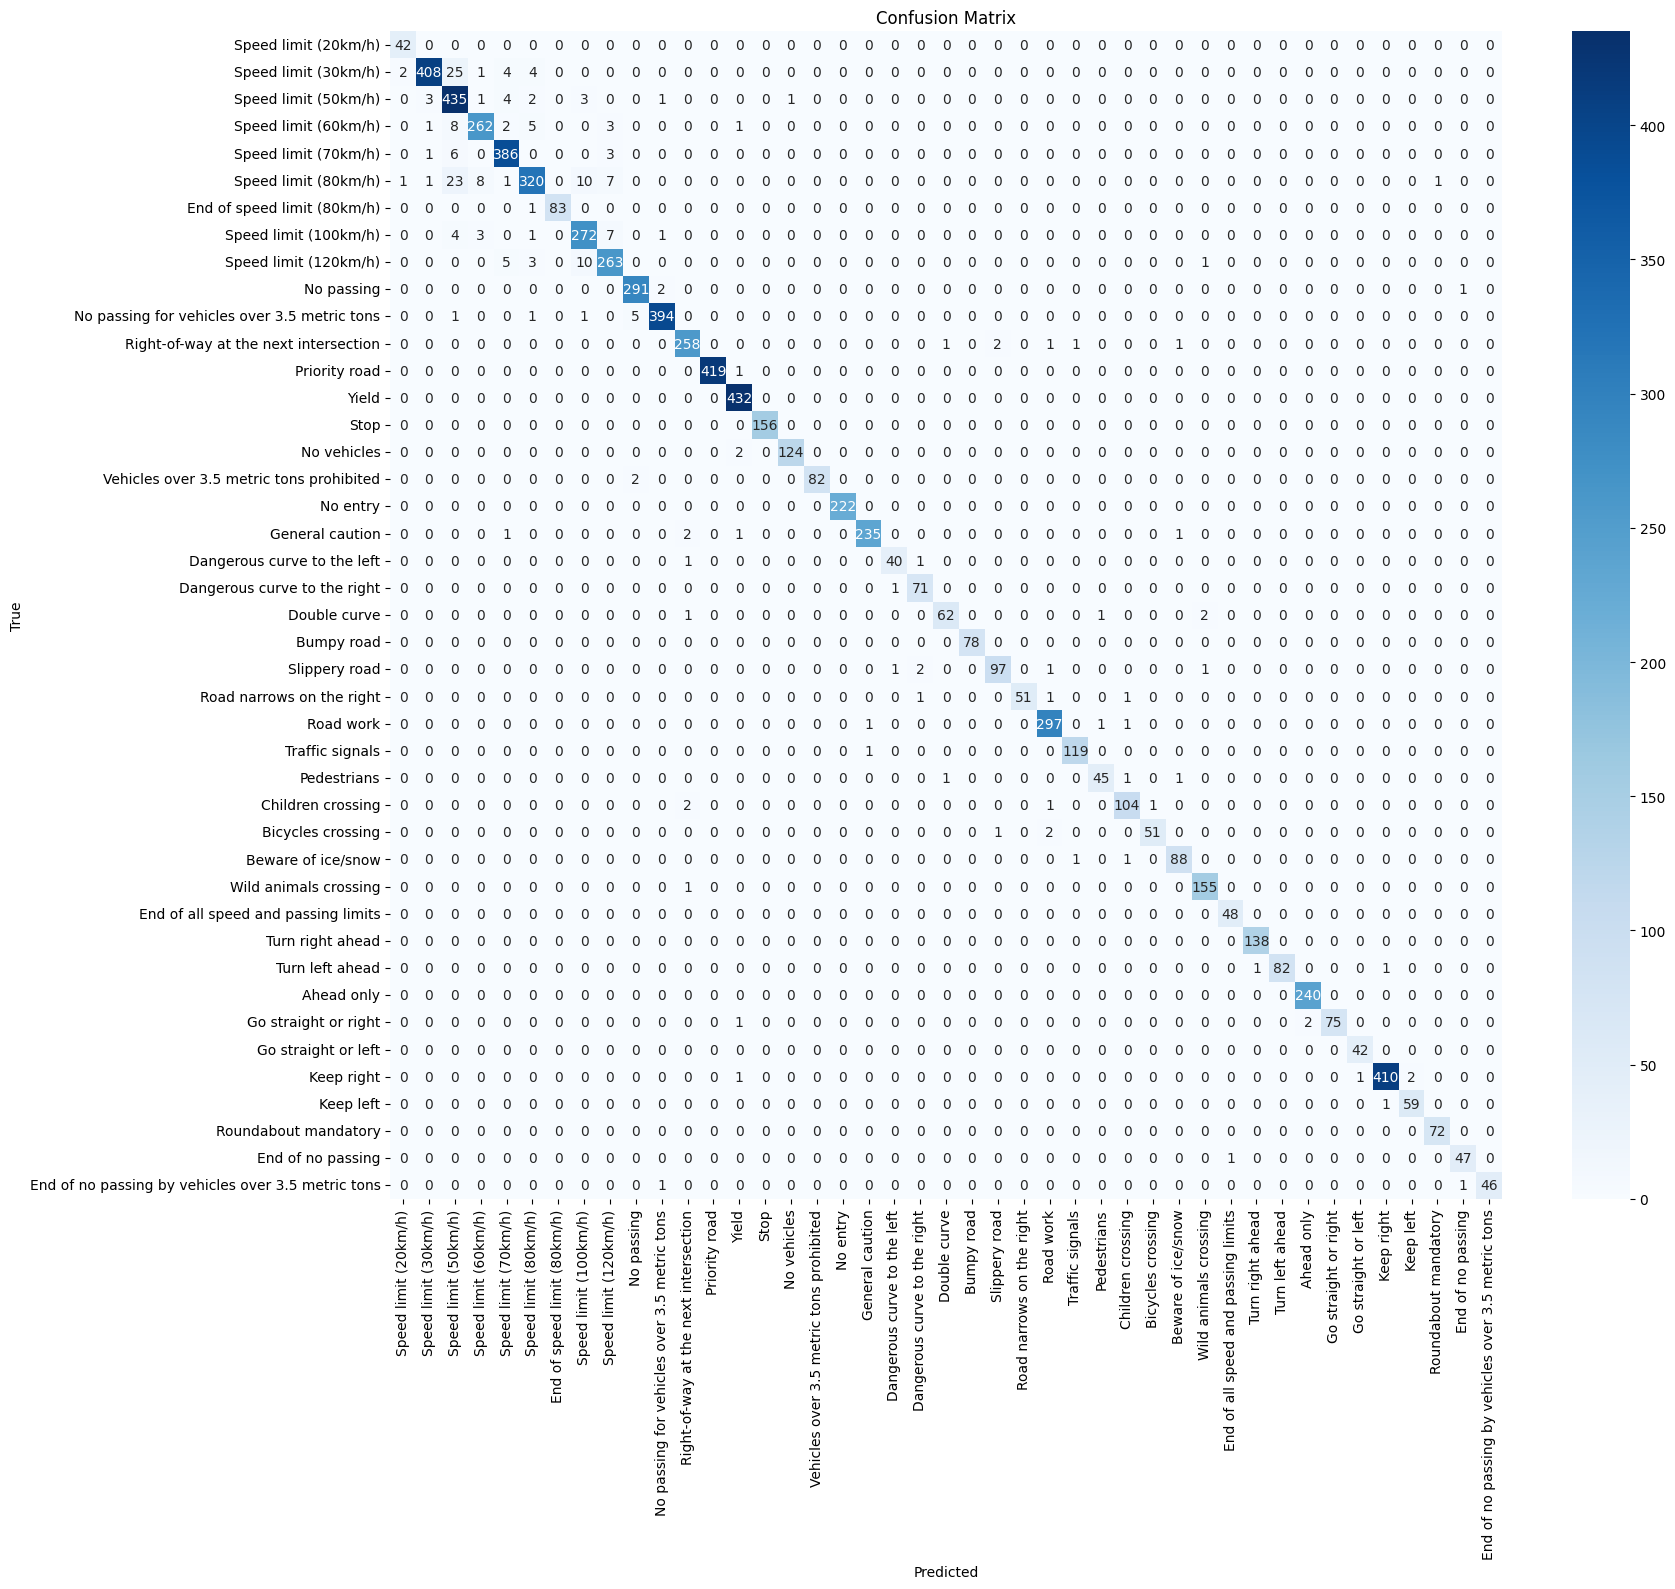

In [40]:
import onnxruntime as rt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from PIL import Image
import torchvision.transforms as transforms

sess = rt.InferenceSession("model/traffic_sign_model2.onnx")

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

all_preds = []
all_labels_list = []

for img_path, label in zip(test_paths, y_test):
    img = Image.open(img_path).convert("RGB")
    tensor = test_transforms(img).unsqueeze(0).numpy()
    pred = int(np.argmax(sess.run(None, {"input": tensor})[0][0]))
    all_preds.append(pred)
    all_labels_list.append(label)

all_preds = np.array(all_preds)
all_labels = np.array(all_labels_list)

test_accuracy = (all_preds == all_labels).mean() * 100
print(f"Test accuracy: {test_accuracy:.2f}%")

print(classification_report(all_labels, all_preds, target_names=list(class_names.values())))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(18, 16))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names.values(),
            yticklabels=class_names.values())
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

In [ ]:
import onnxruntime as rt
import numpy as np
from PIL import Image
import torchvision.transforms as transforms
import os
import time

sess = rt.InferenceSession("model/traffic_sign_model2.onnx")

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

labels = {}
with open("ground_truth.csv") as f:
    next(f)
    for line in f:
        fname, cls = line.strip().split(",")
        labels[fname] = int(cls)

correct = 0
total = 0
total_time = 0.0
min_time = float('inf')
max_time = 0.0

for fname, true_class in labels.items():
    path = os.path.join("ppm_test", fname)
    if not os.path.exists(path):
        continue

    start = time.perf_counter()
    img = Image.open(path).convert("RGB")
    tensor = test_transforms(img).unsqueeze(0).numpy()
    pred = int(np.argmax(sess.run(None, {"input": tensor})[0][0]))
    end = time.perf_counter()

    elapsed = (end - start) * 1000.0
    total_time += elapsed
    if elapsed < min_time: min_time = elapsed
    if elapsed > max_time: max_time = elapsed

    if pred == true_class:
        correct += 1
    total += 1

avg_time = total_time / total
fps = 1000.0 / avg_time

print(f"\n--------------------------------------")
print(f"MODEL SUMMARY")
print(f"--------------------------------------")
print(f"{total} images processed")
print(f"Accuracy: {correct/total*100:.2f}% ({correct}/{total})")
print(f"Average time: {avg_time:.2f} ms/image")
print(f"Total time: {total_time:.2f} ms")
print(f"\n--------------------------------------")
print(f"BENCHMARK RESULTS")
print(f"--------------------------------------")
print(f"{total} images processed")
print(f"Average time: {avg_time:.2f} ms/image")
print(f"Min time: {min_time:.2f} ms/image")
print(f"Max time: {max_time:.2f} ms/image")
print(f"Total time: {total_time:.2f} ms")
print(f"FPS: {fps:.2f} FPS")


--------------------------------------
MODEL SUMMARY
--------------------------------------
1000 images processed
Accuracy: 91.10% (911/1000)
Average time: 30.45 ms/image
Total time: 30448.95 ms

--------------------------------------
BENCHMARK RESULTS
--------------------------------------
1000 images processed
Average time: 30.45 ms/image
Min time: 5.26 ms/image
Max time: 134.45 ms/image
Total time: 30448.95 ms
FPS: 32.84 FPS
